# Ensemble Learning - Gradient Bosting 

### What is Gradient Boosting?

**Gradient Boosting** is a powerful ensemble technique that builds models **one at a time**, where each new model tries to fix the mistakes (residuals) made by the previous one.

Think of it like a team of students correcting each other's work:
- Student 1 attempts the problem and gets some answers wrong.
- Student 2 looks at only what Student 1 got wrong and tries to fix those.
- Student 3 fixes what Student 2 still got wrong, and so on.

At the end, you combine all their efforts to get the best possible answer.

### Key Concepts

|  ||
|------|---------|
| **Residual** | The error between actual and predicted value |
| **Weak Learner** | A simple model (like a shallow Decision Tree) used at each step |
| **Learning Rate (lr)** | Controls how much each tree contributes to the final prediction |
| **Ensemble** | Combining many models to make one strong prediction |

### How It Works 

1. Start with a simple prediction — the **mean** of the target values.
2. Calculate the **residuals** (errors) from this prediction.
3. Train a Decision Tree on these residuals.
4. Add the tree's predictions to the previous prediction.
5. Calculate new residuals and repeat until satisfied.
---

### Import Libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

### Generating Dataset 

We create a synthetic dataset with:
- **X**  -> 100 random values between -0.5 and 0.5
- **y**  -> y = 3·X² + small noise

In [68]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [69]:
data = pd.DataFrame()
data['X'] = X.reshape(100)
data['y'] = y
data.head(4)

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178


### Scatter plot for data points 

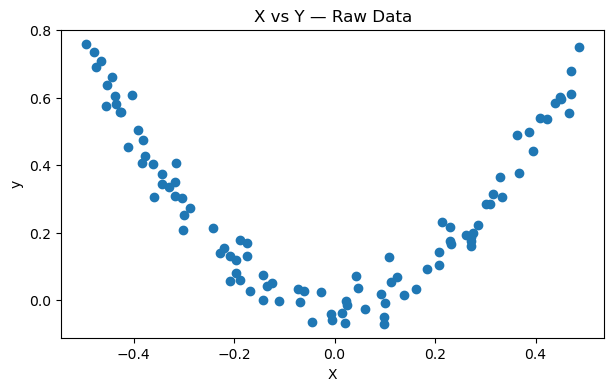

In [71]:
plt.figure(figsize=(7, 4))
plt.scatter(data['X'], data['y'])  # Scatter plot of raw data
plt.title('X vs Y — Raw Data')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

### First Prediction — Use the Mean

In Gradient Boosting, the **first prediction** is just the **mean of y**.

This is the simplest possible model. Then we calculate the **residuals** (how far off we are from the real values):

```
residual = actual_y - predicted_y
```

A **positive residual** means we under-predicted. A **negative residual** means we over-predicted.

In [73]:
data['pred_1'] = data['y'].mean()
data['residual_1'] = data['y'] - data['pred_1']
data.head(4)

,X,y,pred_1,residual_1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636


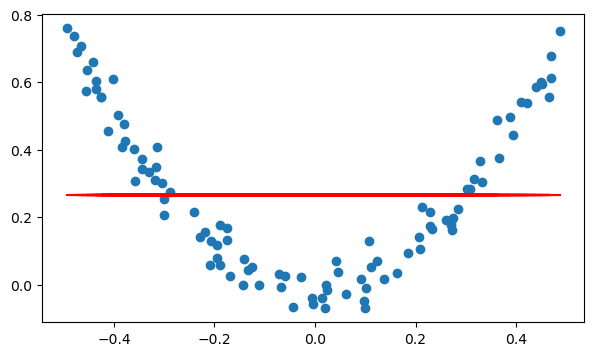

In [74]:
plt.figure(figsize=(7,4))
plt.scatter(data['X'],data['y'])
plt.plot(data['X'],data['pred_1'],color='red')
plt.show()

### Train Decision Tree #1 on the Residuals

Now we train a **Decision Tree** to predict the **residuals** (errors), not the original y.
Limit the tree to `max_leaf_nodes=8` to keep it shallow (a "weak learner").

> **Why train on residuals?**  
> Because want the next model to learn "where did the previous model go wrong?"

In [76]:
# Train Decision Tree #1 on the residuals from prediction 1
decision_tree1 = DecisionTreeRegressor(max_leaf_nodes=8)
decision_tree1.fit(
    data['X'].values.reshape(100, 1),  # Feature (must be 2D)
    data['residual_1'].values           # Target = residuals, not y!
)

DecisionTreeRegressor(max_leaf_nodes=8)

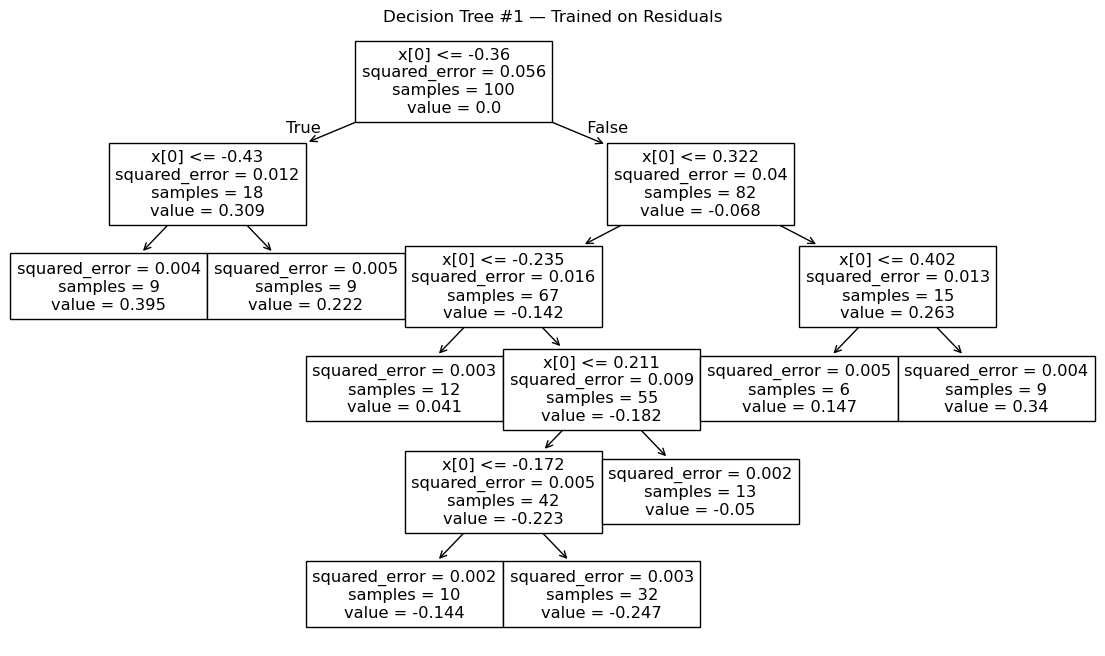

In [77]:
# Visualize the tree structure
# Each leaf node shows the average residual it predicts
plt.figure(figsize=(14,8))
plot_tree(decision_tree1)
plt.title('Decision Tree #1 — Trained on Residuals')
plt.show()

###  Improved Prediction After Tree #1

The new prediction is:
```
pred = mean(y) + Tree1.predict(X)
     = 0.265458 + residual_correction
```

- The value `0.265458` is the mean of y (initial baseline prediction).
- plot the updated curve over the data.

### Generating X_test Column 

In [80]:
# Create a dense test set for smooth curve plotting
X_test = np.linspace(-0.5, 0.5, 500)

# New prediction = baseline mean + Tree1's correction for residuals
# 0.265458 is the mean of y (pred_1)
y_pred = 0.265458 + decision_tree1.predict(X_test.reshape(500, 1))

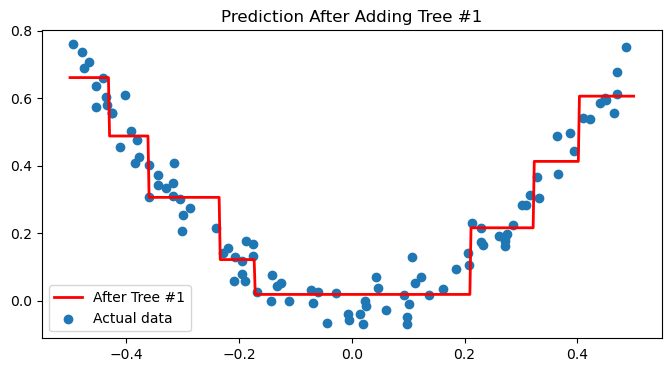

In [81]:
# Plot: The red curve is now closer to the U-shape!
plt.figure(figsize=(8,4))
plt.plot(X_test, y_pred, linewidth=2, color='red', label='After Tree #1')
plt.scatter(data['X'], data['y'], label='Actual data')
plt.title('Prediction After Adding Tree #1')
plt.legend()
plt.show()

### Second Iteration — New Residuals and Tree #2
- Update the predictions using Tree #1, then calculate **new residuals** (what's still wrong?).
- Then train **Tree #2** on these new (smaller) residuals.

In [83]:
# Update prediction using Tree #1's corrections
data['pred_2'] = 0.265458 + decision_tree1.predict(data['X'].values.reshape(100, 1))

# Residual 2: new errors after the first correction
data['residual_2'] = data['y'] - data['pred_2']

data.head(4)  # Notice residuals are now smaller than residual_1!

,X,y,pred_1,residual_1,pred_2,residual_2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497


In [84]:
# Train Decision Tree #2 on the NEW (updated) residuals
decision_tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
decision_tree2.fit(
    data['X'].values.reshape(100, 1),
    data['residual_1'].values  # Note: still using residual_1 here (original boosting pattern)
)

DecisionTreeRegressor(max_leaf_nodes=8)

In [85]:
# New prediction = baseline + sum of all trees' residual corrections
y_pred = 0.265458 + sum(
    regressor.predict(X_test.reshape(-1, 1))
    for regressor in [decision_tree1, decision_tree2]
)

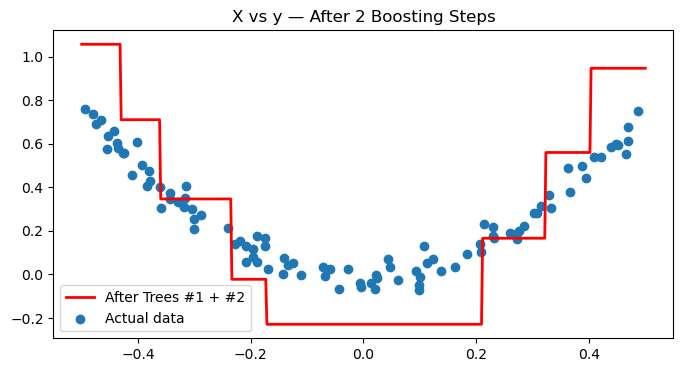

In [86]:
# Plot: Prediction after 2 trees — should be even closer to the parabola
plt.figure(figsize=(8,4))
plt.plot(X_test, y_pred, linewidth=2, color='red', label='After Trees #1 + #2')
plt.scatter(data['X'], data['y'], label='Actual data')
plt.title('X vs y — After 2 Boosting Steps')
plt.legend()
plt.show()

In [106]:
def gradient_boost(X, y, number, lr, count=1, regs=[], foo=None):
    """
    Recursive Gradient Boosting implementation.
    
    Args:
        X      : Input features (2D array)
        y      : Target (becomes residuals in recursion)
        number : Remaining boosting rounds
        lr     : Learning rate (how much each tree contributes)
        count  : Current iteration (default 1)
        regs   : List of trained weak learners
        foo    : Original y values (for plotting)
    """

    # Base case: stop recursion when no rounds are left
    if number == 0:
        return

    else:
        # --- GRADIENT BOOSTING CORE ---

        if count > 1:
            # After the first round, compute NEW residuals:
            # y = actual - previous_tree_prediction
            y = y - regs[-1].predict(X)
        else:
            # On the first round, save original y for plotting
            foo = y

        # Train a shallow Decision Tree on residuals (weak learner)
        tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
        tree_reg.fit(X, y)
        regs.append(tree_reg)  # Add to the ensemble

        # Dense X for smooth prediction curve
        x1 = np.linspace(-0.5, 0.5, 500)

        # Cumulative prediction: sum all trees (scaled by learning rate)
        y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

        # Print which round this is
        print(number)

        # Plot prediction vs actual data
        plt.figure()
        plt.plot(x1, y_pred, linewidth=2, label=f'Round {count} prediction')
        plt.plot(X[:, 0], foo, "r.", label='Actual data')  # original y as dots
        plt.title(f'Gradient Boosting — {count} Tree(s)')
        plt.legend()
        plt.show()

        # --- RECURSIVE CALL for next round ---
        gradient_boost(X, y, number - 1, lr, count + 1, regs, foo=foo)

5


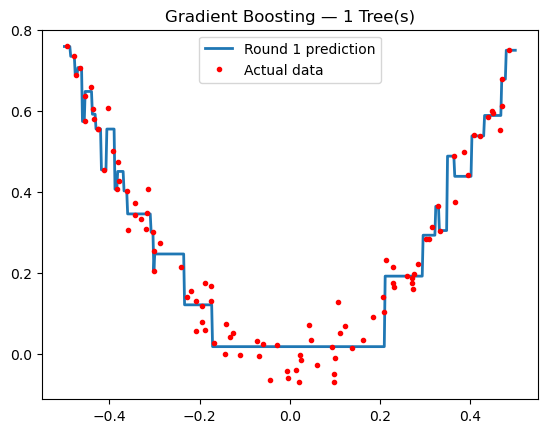

4


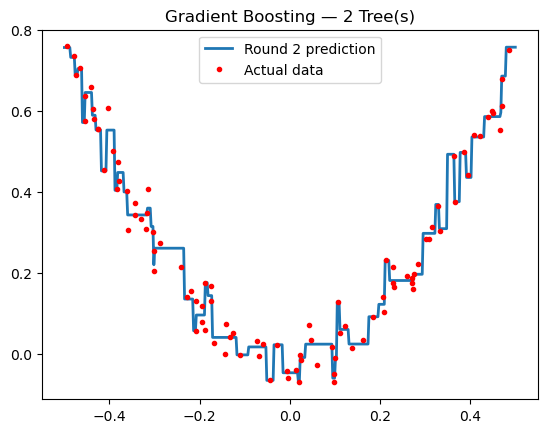

3


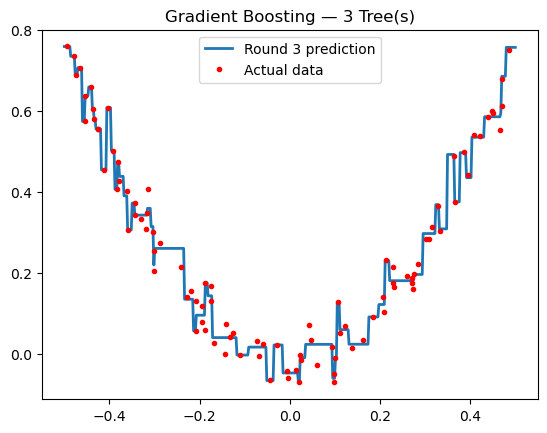

2


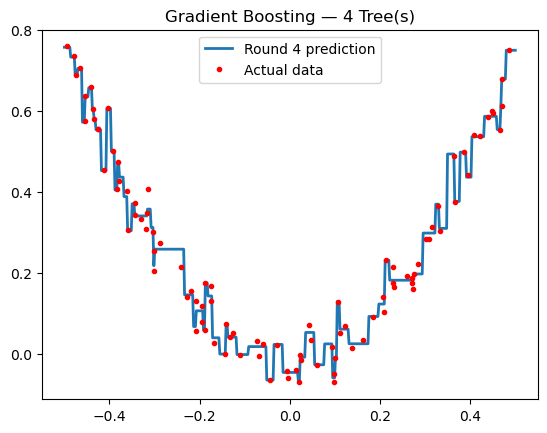

1


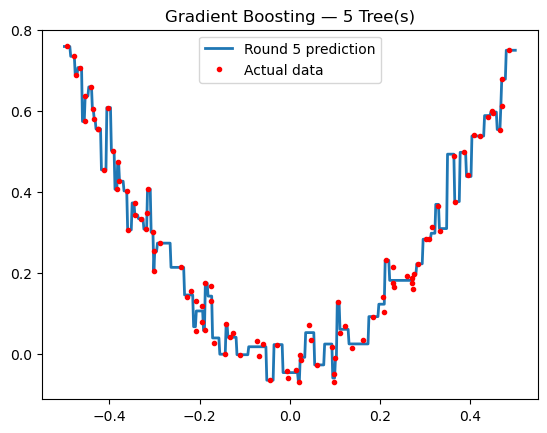

In [108]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)